# ENG-06: QC Report Generation

This notebook walks through the ENG-06 QC Report pipeline, demonstrating how to:

1. Discover and load QC metadata produced by ENG-03 (artifact rejection)
2. Compute derived metrics (drop rates, SNR estimates, ICA summaries)
3. Generate an HTML QC dashboard and summary CSV
4. Visualize key QC metrics with matplotlib

**Data source:** If ENG-03 has been run, the notebook uses real QC parquet files.
Otherwise it generates realistic synthetic data so the full pipeline can be demonstrated.

In [1]:
import os
import sys

# Ensure imports resolve from the project root (awaken-ai/)
os.chdir(os.path.join(os.path.abspath("."), ".."))
sys.path.insert(0, os.getcwd())

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

print(f"NumPy {np.__version__}  •  pandas {pd.__version__}")
print(f"Working directory: {os.getcwd()}")

NumPy 1.26.4  •  pandas 2.2.3
Working directory: /Users/riddheshsawant/Downloads/Capstone/awaken-ai


## 1. Discover and Load QC Data

The `QCDataCollector` scans `data/processed/qc/` for all `eng03_qc.parquet` files
and concatenates them into a single DataFrame.

In [2]:
from src.data_processing.qc_report import QCDataCollector

collector = QCDataCollector()

# Show available QC files
qc_files = collector.discover_qc_files()
print(f"Found {len(qc_files)} QC file(s):")
for f in qc_files:
    print(f"  {f}")

sessions = collector.get_available_sessions()
print(f"\nAvailable sessions: {sessions}")

USE_REAL_DATA = len(qc_files) > 0
if USE_REAL_DATA:
    print("\n>> Using REAL QC data from ENG-03 output.")
else:
    print("\n>> No ENG-03 output found. Generating synthetic QC data for demo.")

Found 2 QC file(s):
  /Users/riddheshsawant/Downloads/Capstone/awaken-ai/data/processed/qc/CON008/2025-08-14/eng03_qc.parquet
  /Users/riddheshsawant/Downloads/Capstone/awaken-ai/data/processed/qc/CON009/2025-08-26/eng03_qc.parquet

Available sessions: [('CON008', '2025-08-14'), ('CON009', '2025-08-26')]

>> Using REAL QC data from ENG-03 output.


In [3]:
import json

def _synthetic_qc_data():
    """Generate realistic synthetic QC data matching the ENG-03 schema.
    Used only when no real QC parquets exist yet.
    """
    def _ica_json(method="iclabel", excluded=None, eog=None, muscle=None):
        return json.dumps({
            "method": "infomax", "classification_method": method,
            "n_components": 15, "n_components_selected": None,
            "excluded": excluded or [1, 3], "eog_channels_used": ["Fp1", "Fp2"],
            "eog_components": eog or [1], "ecg_channels_used": [], "ecg_components": [],
            "muscle_components": muscle or [3], "line_noise_components": [],
            "channel_noise_components": [], "iclabel_labels": None,
            "iclabel_probs": None, "notes": [],
        })

    rows = [
        dict(patient_id="CON008", date="2025-08-14", trial_type="language",
             window_sec=16.0, reject_ptp_percentile=95.0, reject_ptp_threshold_uv=120.5,
             n_epochs_total=72, n_epochs_dropped=4, n_epochs_kept=68,
             drop_reason="ENG03_PTP_GT_P95", ica=_ica_json(), notes="[]",
             ptp_uv_p50=45.0, ptp_uv_p95=110.0, ptp_uv_p99=150.0, ptp_uv_max=200.0, ptp_uv_mean=55.0),
        dict(patient_id="CON008", date="2025-08-14", trial_type="oddball",
             window_sec=35.0, reject_ptp_percentile=95.0, reject_ptp_threshold_uv=95.3,
             n_epochs_total=4, n_epochs_dropped=0, n_epochs_kept=4,
             drop_reason=None, ica=_ica_json(), notes="[]",
             ptp_uv_p50=30.0, ptp_uv_p95=80.0, ptp_uv_p99=90.0, ptp_uv_max=100.0, ptp_uv_mean=35.0),
        dict(patient_id="CON008", date="2025-08-14", trial_type="left_command",
             window_sec=200.0, reject_ptp_percentile=95.0, reject_ptp_threshold_uv=140.0,
             n_epochs_total=8, n_epochs_dropped=1, n_epochs_kept=7,
             drop_reason="ENG03_PTP_GT_P95", ica=_ica_json(), notes="[]",
             ptp_uv_p50=50.0, ptp_uv_p95=130.0, ptp_uv_p99=170.0, ptp_uv_max=250.0, ptp_uv_mean=60.0),
        dict(patient_id="CON008", date="2025-08-14", trial_type="right_command",
             window_sec=200.0, reject_ptp_percentile=95.0, reject_ptp_threshold_uv=135.0,
             n_epochs_total=8, n_epochs_dropped=1, n_epochs_kept=7,
             drop_reason="ENG03_PTP_GT_P95",
             ica=_ica_json("correlation", [0, 2], [0], [2]), notes="[]",
             ptp_uv_p50=48.0, ptp_uv_p95=125.0, ptp_uv_p99=165.0, ptp_uv_max=230.0, ptp_uv_mean=58.0),
    ]
    return pd.DataFrame(rows)

# Load real QC data, or fall back to synthetic
if USE_REAL_DATA:
    qc_df = collector.load_all()
else:
    qc_df = _synthetic_qc_data()

print(f"QC DataFrame shape: {qc_df.shape}")
print(f"Columns: {list(qc_df.columns)}")
qc_df

QC DataFrame shape: (8, 17)
Columns: ['patient_id', 'date', 'trial_type', 'window_sec', 'reject_ptp_percentile', 'reject_ptp_threshold_uv', 'n_epochs_total', 'n_epochs_dropped', 'n_epochs_kept', 'drop_reason', 'ica', 'notes', 'ptp_uv_p50', 'ptp_uv_p95', 'ptp_uv_p99', 'ptp_uv_max', 'ptp_uv_mean']


,patient_id,date,trial_type,window_sec,reject_ptp_percentile,reject_ptp_threshold_uv,n_epochs_total,n_epochs_dropped,n_epochs_kept,drop_reason,ica,notes,ptp_uv_p50,ptp_uv_p95,ptp_uv_p99,ptp_uv_max,ptp_uv_mean
0,CON008,2025-08-14,language,16.0,95.0,311.763114,72,4,68,ENG03_PTP_GT_P95,"{""channel_noise_components"": [], ""classificati...",[],142.847873,311.763114,680.810251,695.314585,169.913127
1,CON008,2025-08-14,left_command,200.0,95.0,413.296467,3,1,2,ENG03_PTP_GT_P95,"{""channel_noise_components"": [], ""classificati...",[],197.215432,413.296467,432.503670,437.305471,261.913348
2,CON008,2025-08-14,oddball,35.0,95.0,153.423844,4,1,3,ENG03_PTP_GT_P95,"{""channel_noise_components"": [], ""classificati...",[],145.831505,153.423844,153.722821,153.797566,145.616063
3,CON008,2025-08-14,right_command,200.0,95.0,690.047112,3,1,2,ENG03_PTP_GT_P95,"{""channel_noise_components"": [], ""classificati...",[],257.678143,690.047112,728.479910,738.088109,398.106467
4,CON009,2025-08-26,language,16.0,95.0,531.229972,72,4,68,ENG03_PTP_GT_P95,"{""channel_noise_components"": [], ""classificati...",[],182.151476,531.229972,4477.582528,10921.735614,397.105817
5,CON009,2025-08-26,left_command,200.0,95.0,5023.085417,3,1,2,ENG03_PTP_GT_P95,"{""channel_noise_components"": [], ""classificati...",[],1177.015850,5023.085417,5364.958268,5450.426481,2306.808589
6,CON009,2025-08-26,oddball,35.0,95.0,243.826781,4,1,3,ENG03_PTP_GT_P95,"{""channel_noise_components"": [], ""classificati...",[],212.350295,243.826781,246.293711,246.910443,213.679277
7,CON009,2025-08-26,right_command,200.0,95.0,445.099985,3,1,2,ENG03_PTP_GT_P95,"{""channel_noise_components"": [], ""classificati...",[],310.769005,445.099985,457.040516,460.025649,336.247523


## 2. Compute Derived Metrics

The `QCMetricsCalculator` enriches the raw QC data with:
- **Drop rates** (fraction of epochs rejected)
- **SNR estimates** (signal-to-noise ratio from PTP statistics)
- **ICA summaries** (component exclusion counts by artifact type)

In [4]:
from src.data_processing.qc_report import QCMetricsCalculator

calculator = QCMetricsCalculator(qc_df)
metrics_df = calculator.compute_all_metrics()

print(f"Enriched DataFrame shape: {metrics_df.shape}")
print(f"New columns added: {[c for c in metrics_df.columns if c not in qc_df.columns]}")
metrics_df.head(10)

Enriched DataFrame shape: (8, 27)
New columns added: ['drop_rate', 'snr_db', 'ica_method', 'ica_classification_method', 'ica_n_components_excluded', 'ica_n_eog', 'ica_n_ecg', 'ica_n_muscle', 'ica_n_line_noise', 'ica_n_channel_noise']


,patient_id,date,trial_type,window_sec,reject_ptp_percentile,reject_ptp_threshold_uv,n_epochs_total,n_epochs_dropped,n_epochs_kept,drop_reason,...,drop_rate,snr_db,ica_method,ica_classification_method,ica_n_components_excluded,ica_n_eog,ica_n_ecg,ica_n_muscle,ica_n_line_noise,ica_n_channel_noise
0,CON008,2025-08-14,language,16.0,95.0,311.763114,72,4,68,ENG03_PTP_GT_P95,...,0.055556,-6.779019,infomax,iclabel,5,2,0,1,2,0
1,CON008,2025-08-14,left_command,200.0,95.0,413.296467,3,1,2,ENG03_PTP_GT_P95,...,0.333333,-6.426416,infomax,iclabel,5,2,0,1,2,0
2,CON008,2025-08-14,oddball,35.0,95.0,153.423844,4,1,3,ENG03_PTP_GT_P95,...,0.250000,-0.440830,infomax,iclabel,5,2,0,1,2,0
3,CON008,2025-08-14,right_command,200.0,95.0,690.047112,3,1,2,ENG03_PTP_GT_P95,...,0.333333,-8.556023,infomax,iclabel,5,2,0,1,2,0
4,CON009,2025-08-26,language,16.0,95.0,531.229972,72,4,68,ENG03_PTP_GT_P95,...,0.055556,-9.296997,infomax,iclabel,4,1,0,0,3,0
5,CON009,2025-08-26,left_command,200.0,95.0,5023.085417,3,1,2,ENG03_PTP_GT_P95,...,0.333333,-12.603765,infomax,iclabel,4,1,0,0,3,0
6,CON009,2025-08-26,oddball,35.0,95.0,243.826781,4,1,3,ENG03_PTP_GT_P95,...,0.250000,-1.200571,infomax,iclabel,4,1,0,0,3,0
7,CON009,2025-08-26,right_command,200.0,95.0,445.099985,3,1,2,ENG03_PTP_GT_P95,...,0.333333,-3.120398,infomax,iclabel,4,1,0,0,3,0


## 3. Visualize Drop Rates per Patient

Bar chart showing the mean epoch drop rate for each patient.

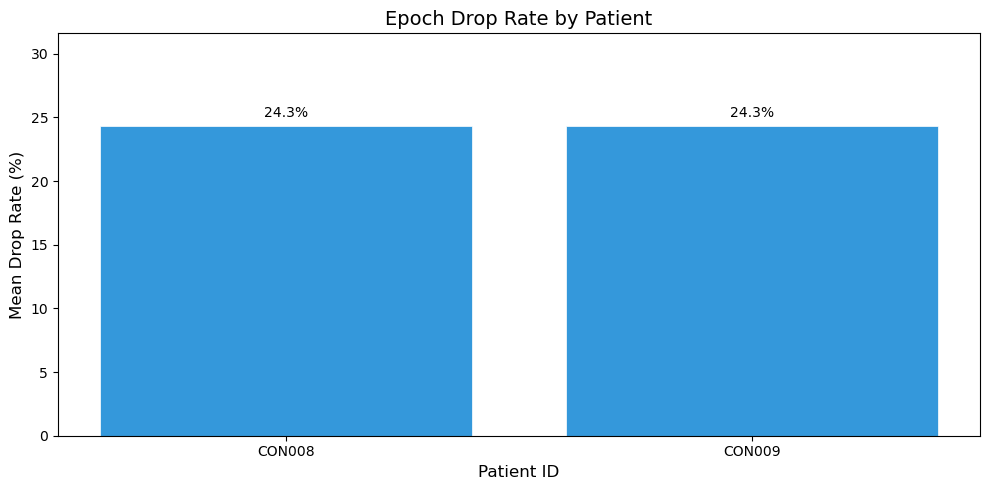

In [5]:
if not metrics_df.empty and "drop_rate" in metrics_df.columns:
    patient_summary = calculator.summary_by_patient()
    
    fig, ax = plt.subplots(figsize=(10, 5))
    patients = patient_summary["patient_id"]
    drop_rates = patient_summary["mean_drop_rate"] * 100
    
    bars = ax.bar(patients, drop_rates, color="#3498db", edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Patient ID", fontsize=12)
    ax.set_ylabel("Mean Drop Rate (%)", fontsize=12)
    ax.set_title("Epoch Drop Rate by Patient", fontsize=14)
    ax.set_ylim(0, max(drop_rates.max() * 1.3, 10))
    
    for bar, rate in zip(bars, drop_rates):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{rate:.1f}%", ha="center", va="bottom", fontsize=10)
    
    plt.tight_layout()
    plt.show()
else:
    print("No data available for plotting.")

## 4. Visualize SNR Metrics per Trial Type

Box plot showing the distribution of SNR (dB) across different trial types.

/var/folders/bq/k86td0xx0dz_dhc2xtnx5xtw0000gn/T/ipykernel_65715/979192191.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(snr_data, labels=trial_types, patch_artist=True,


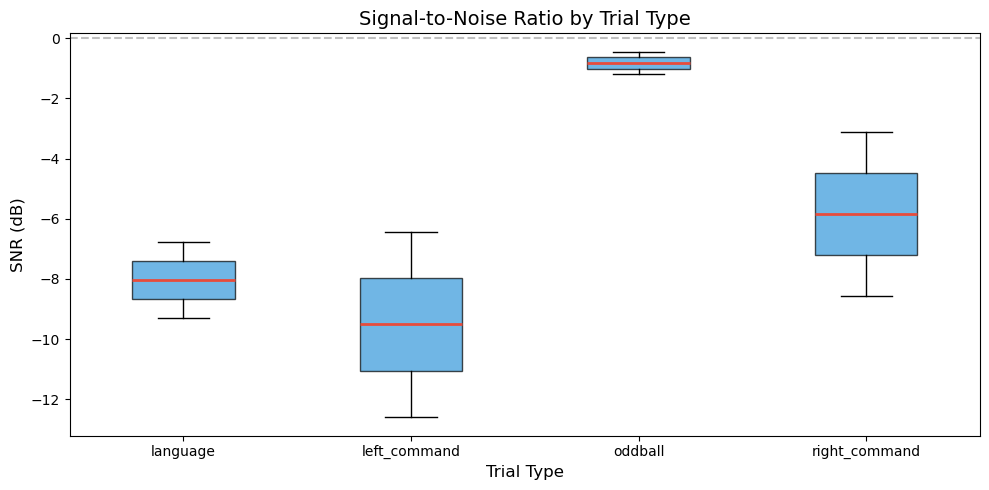

In [6]:
if not metrics_df.empty and "snr_db" in metrics_df.columns:
    trial_types = metrics_df["trial_type"].unique()
    snr_data = [metrics_df[metrics_df["trial_type"] == tt]["snr_db"].dropna().values
                for tt in trial_types]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    bp = ax.boxplot(snr_data, labels=trial_types, patch_artist=True,
                    boxprops=dict(facecolor="#3498db", alpha=0.7),
                    medianprops=dict(color="#e74c3c", linewidth=2))
    ax.set_xlabel("Trial Type", fontsize=12)
    ax.set_ylabel("SNR (dB)", fontsize=12)
    ax.set_title("Signal-to-Noise Ratio by Trial Type", fontsize=14)
    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No SNR data available for plotting.")

## 5. ICA Component Summary

Stacked bar chart showing the number of excluded ICA components by artifact type.

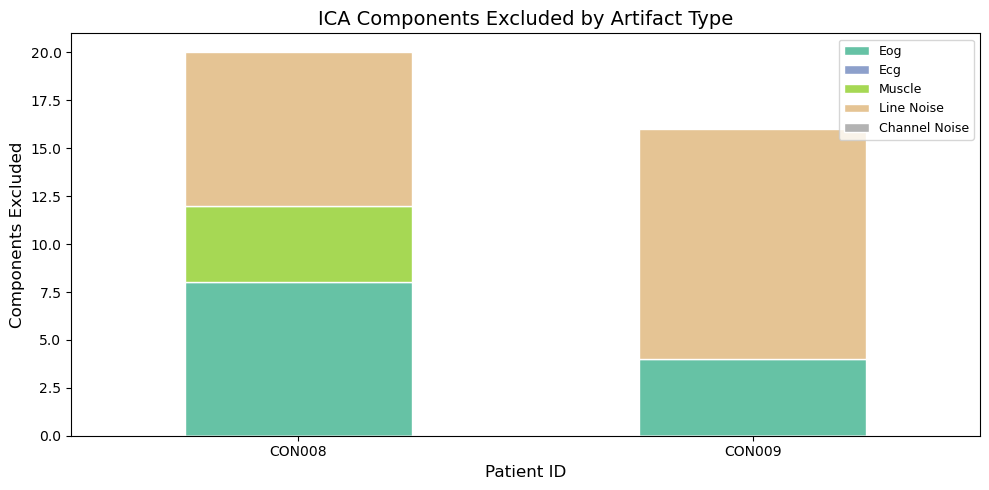

In [7]:
ica_cols = ["ica_n_eog", "ica_n_ecg", "ica_n_muscle", "ica_n_line_noise", "ica_n_channel_noise"]
available_ica = [c for c in ica_cols if c in metrics_df.columns]

if not metrics_df.empty and available_ica:
    ica_by_patient = metrics_df.groupby("patient_id")[available_ica].sum()
    
    fig, ax = plt.subplots(figsize=(10, 5))
    labels = [c.replace("ica_n_", "").replace("_", " ").title() for c in available_ica]
    ica_by_patient.plot(kind="bar", stacked=True, ax=ax, colormap="Set2", edgecolor="white")
    ax.set_xlabel("Patient ID", fontsize=12)
    ax.set_ylabel("Components Excluded", fontsize=12)
    ax.set_title("ICA Components Excluded by Artifact Type", fontsize=14)
    ax.legend(labels, loc="upper right", fontsize=9)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No ICA data available for plotting.")

## 6. Summary Tables

Aggregated summaries grouped by patient and by trial type.

In [8]:
print("=" * 60)
print("Summary by Patient")
print("=" * 60)
patient_summary = calculator.summary_by_patient()
display(patient_summary) if not patient_summary.empty else print("No data.")

print("\n" + "=" * 60)
print("Summary by Trial Type")
print("=" * 60)
trial_summary = calculator.summary_by_trial_type()
display(trial_summary) if not trial_summary.empty else print("No data.")

Summary by Patient


,patient_id,n_epochs_total,n_epochs_dropped,n_epochs_kept,mean_drop_rate,mean_snr_db,mean_ptp_uv,n_sessions
0,CON008,82,7,75,0.243056,-5.550572,243.887251,4
1,CON009,82,7,75,0.243056,-6.555433,813.460302,4



Summary by Trial Type


,trial_type,n_epochs_total,n_epochs_dropped,n_epochs_kept,mean_drop_rate,mean_snr_db,mean_ptp_uv,n_sessions
0,language,144,8,136,0.055556,-8.038008,283.509472,2
1,left_command,6,2,4,0.333333,-9.515090,1284.360968,2
2,oddball,8,2,6,0.250000,-0.820700,179.647670,2
3,right_command,6,2,4,0.333333,-5.838210,367.176995,2


## 7. Generate HTML Report

The `QCReportGenerator` produces a self-contained HTML dashboard.

In [9]:
from src.data_processing.qc_report import QCReportGenerator

generator = QCReportGenerator(metrics_df)
report_path = generator.generate()
print(f"HTML report saved to: {report_path}")

csv_path = generator.save_summary_csv()
print(f"Summary CSV saved to: {csv_path}")

HTML report saved to: /Users/riddheshsawant/Downloads/Capstone/awaken-ai/data/processed/reports/qc_report.html
Summary CSV saved to: /Users/riddheshsawant/Downloads/Capstone/awaken-ai/data/processed/reports/qc_summary.csv


## 8. Display Report Inline

Render the HTML report directly in the notebook.

In [10]:
from IPython.display import IFrame

# Display the generated HTML report inline
if report_path.exists():
    display(IFrame(src=str(report_path), width="100%", height=800))
else:
    print("Report file not found.")

## 9. Quick One-Call Report Generation

For convenience, `generate_qc_report()` chains all three steps in one call.

In [11]:
from src.data_processing.qc_report import generate_qc_report

# One-call convenience function
report_path = generate_qc_report()
print(f"Report generated at: {report_path}")

Report generated at: /Users/riddheshsawant/Downloads/Capstone/awaken-ai/data/processed/reports/qc_report.html


## 10. Inspect Summary CSV

The summary CSV is a machine-readable output for downstream pipelines (MOD-01, VIS-02).

In [12]:
from src.data_loading import config

csv_path = config.REPORTS_DIR / "qc_summary.csv"
if csv_path.exists():
    summary_csv = pd.read_csv(csv_path)
    print(f"Summary CSV shape: {summary_csv.shape}")
    display(summary_csv)
else:
    print("Summary CSV not found. Run the report generator first.")

Summary CSV shape: (8, 27)


,patient_id,date,trial_type,window_sec,reject_ptp_percentile,reject_ptp_threshold_uv,n_epochs_total,n_epochs_dropped,n_epochs_kept,drop_reason,...,drop_rate,snr_db,ica_method,ica_classification_method,ica_n_components_excluded,ica_n_eog,ica_n_ecg,ica_n_muscle,ica_n_line_noise,ica_n_channel_noise
0,CON008,2025-08-14,language,16.0,95.0,311.763114,72,4,68,ENG03_PTP_GT_P95,...,0.055556,-6.779019,infomax,iclabel,5,2,0,1,2,0
1,CON008,2025-08-14,left_command,200.0,95.0,413.296467,3,1,2,ENG03_PTP_GT_P95,...,0.333333,-6.426416,infomax,iclabel,5,2,0,1,2,0
2,CON008,2025-08-14,oddball,35.0,95.0,153.423844,4,1,3,ENG03_PTP_GT_P95,...,0.250000,-0.440830,infomax,iclabel,5,2,0,1,2,0
3,CON008,2025-08-14,right_command,200.0,95.0,690.047112,3,1,2,ENG03_PTP_GT_P95,...,0.333333,-8.556023,infomax,iclabel,5,2,0,1,2,0
4,CON009,2025-08-26,language,16.0,95.0,531.229972,72,4,68,ENG03_PTP_GT_P95,...,0.055556,-9.296997,infomax,iclabel,4,1,0,0,3,0
5,CON009,2025-08-26,left_command,200.0,95.0,5023.085417,3,1,2,ENG03_PTP_GT_P95,...,0.333333,-12.603765,infomax,iclabel,4,1,0,0,3,0
6,CON009,2025-08-26,oddball,35.0,95.0,243.826781,4,1,3,ENG03_PTP_GT_P95,...,0.250000,-1.200571,infomax,iclabel,4,1,0,0,3,0
7,CON009,2025-08-26,right_command,200.0,95.0,445.099985,3,1,2,ENG03_PTP_GT_P95,...,0.333333,-3.120398,infomax,iclabel,4,1,0,0,3,0
